# Packages

In [1]:
import Pkg
Pkg.add("Plots")
Pkg.add("StatsBase")
Pkg.add("StatsPlots")
Pkg.add("Distributions")
Pkg.add("StatsFuns")

In [2]:
#import Random, Logging
using Plots, Distributions, StatsPlots, LinearAlgebra, StatsFuns, Printf
using StatsBase: mean, countmap
using Distributions: Categorical

# Install Gen Latest Repo Version
The current Gen.jl stable release (v0.4.7) does not ship with `enumerative_inference` in its API. We need to clone the latest Gen.jl repo and proceed with that version.

In [3]:
; git clone https://github.com/probcomp/Gen.jl.git /content/Gen.jl

In [4]:
Pkg.develop(path="/content/Gen.jl")
@show hasproperty(Gen, :enumerative_inference)

# RSA model: Politeness - the case study of white lies

Version 2: Using Gen's new `enumerative_inference` method

## L0

In [5]:
using Gen

# Define state and utterance space
states = [1, 2, 3, 4, 5]
utterances = ["terrible", "bad", "okay", "good", "amazing"]
key_mapping = Dict("terrible" => 1, "bad" => 2, "okay" => 3, "good" => 4, "amazing" => 5)

# Literal semantics represented as probabilities
literalSemantics = Dict(
    "terrible" => [0.95, 0.85, 0.02, 0.02, 0.02],
    "bad" => [0.85, 0.95, 0.02, 0.02, 0.02],
    "okay" => [0.02, 0.25, 0.95, 0.65, 0.35],
    "good" => [0.02, 0.05, 0.55, 0.95, 0.93],
    "amazing" => [0.02, 0.02, 0.02, 0.65, 0.95]
)

prob(utterance::String, state::Int64) = literalSemantics[utterance][state]
@dist meaning(utterance::String, state::Int64) = bernoulli(prob(utterance, state))

@dist uniformDraw(vector::Vector, vectorProbs::Vector{Float64}) = vector[categorical(vectorProbs)]
uniformProbs(vector::Vector) = fill(1 / length(vector), length(vector))
stateProbs = uniformProbs(states)
utterancesProbs = uniformProbs(utterances)

5-element Vector{Float64}:
 0.2
 0.2
 0.2
 0.2
 0.2

In [6]:
@gen function literalListener(stateProbs::Vector{Float64}, utterance::String)
    state = @trace(uniformDraw(states, stateProbs), :state)
    m = @trace(meaning(utterance, state), :m)
    return state
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Vector{Float64}, String], false, Union{Nothing, Some{Any}}[nothing, nothing], var"##literalListener#227", Bool[0, 0], false)

In [7]:
# state‐grid iterator
grid_iter = choice_vol_grid((:state, states))

# function to get posterior for one utterance u
function L0_posterior(u::String)
    (traces, log_weights, lml_est) = enumerative_inference(
        literalListener,
        (stateProbs, u),   # stateProbs + single utterance
        choicemap((:m, 1)),# observed m = true at address :m
        grid_iter          # positional iterator for :state
    )
    return Dict(zip(states, exp.(log_weights))), lml_est
end

L0_posterior (generic function with 1 method)

In [8]:
for u in utterances
    posterior, lml = L0_posterior(u)
    println("Utterance = \"$u\" (log-marginal = $(round(lml, digits=3))):")
    for s in states
        @printf("  state=%d → %.3f\n", s, posterior[s])
    end
    println()
end

Utterance = "terrible" (log-marginal = -0.989):
  state=1 → 0.511
  state=2 → 0.457
  state=3 → 0.011
  state=4 → 0.011
  state=5 → 0.011

Utterance = "bad" (log-marginal = -0.989):
  state=1 → 0.457
  state=2 → 0.511
  state=3 → 0.011
  state=4 → 0.011
  state=5 → 0.011

Utterance = "okay" (log-marginal = -0.812):
  state=1 → 0.009
  state=2 → 0.113
  state=3 → 0.428
  state=4 → 0.293
  state=5 → 0.158

Utterance = "good" (log-marginal = -0.693):
  state=1 → 0.008
  state=2 → 0.020
  state=3 → 0.220
  state=4 → 0.380
  state=5 → 0.372

Utterance = "amazing" (log-marginal = -1.103):
  state=1 → 0.012
  state=2 → 0.012
  state=3 → 0.012
  state=4 → 0.392
  state=5 → 0.572



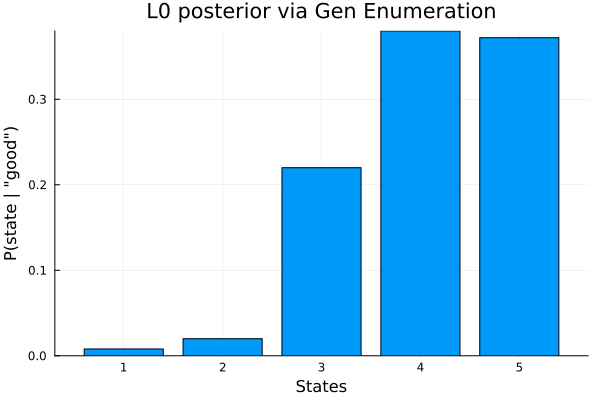

In [9]:
# for utterance = "good"
posterior_on_state, lml = L0_posterior("good")
posterior_vec = [posterior_on_state[s] for s in states]
bar(
  states, posterior_vec;
  xlabel="States",
  ylabel="P(state | \"good\")",
  legend=false,
  title="L0 posterior via Gen Enumeration"
)

## S1

In [10]:
# grid‐iterators for enumeration
state_grid = choice_vol_grid((:state, states))
utter_grid = choice_vol_grid((:utter, utterances))

# S1 utility function defined as a simple Julia function
const λ = 1.25
function S1_util(utt::String, st::Int, φ::Float64)
    α = 10.0
    L0, lml = L0_posterior(utt)
    u_epi = log(L0[st])
    u_soc = sum(k*v for (k,v) in L0) * λ
    return α * (φ * u_epi + (1 - φ) * u_soc)
end

# utilities → normalized choice‐probs
function speaker_log_probs(
    utts::Vector{String}, priors::Vector{Float64},
    util_fn::Function, util_args::Tuple
)
    adjusted = Float64[]
    for (u, p) in zip(utts, priors)
        util = util_fn(u, util_args...)
        push!(adjusted, exp(log(p) + util))
    end
    return adjusted ./ sum(adjusted)
end

# Pragmatic speaker model
@gen function speaker1(st::Int, φ::Float64)
    S1p = speaker_log_probs(
        utterances, utterancesProbs,
        S1_util, (st, φ)
    )
    utt = @trace(uniformDraw(utterances, S1p), :utter)
    return utt
end

# Enumerative inference on speaker1
function utterProbsDict(state::Int, φ::Float64)
    # enumerate over :utter to get exact S₁ posterior for this (state, φ)
    (tr_s1, logw_s1, lml_s1) = enumerative_inference(
        speaker1,
        (state, φ),   # arguments: state and phi
        choicemap(),  # no observations
        utter_grid    # enumerate over utterance choices
    )
    return tr_s1, Dict(zip(utterances, exp.(logw_s1))), lml_s1
end
_, logw_dict, lml_s1 = utterProbsDict(1, 0.99) # state=1, φ=0.99

posterior_s1 = [logw_dict[u] for u in utterances]

5-element Vector{Float64}:
 0.7492118742394185
 0.25078812576058135
 4.1596224755297785e-18
 1.385114251223438e-18
 8.402098677535303e-17

In [11]:
println("Log‐marginal likelihood (speaker1): ", round(lml_s1, digits=3))
println("Posterior P(utterance | state=1, φ=0.99):")
for (u, p) in logw_dict
    @printf("  %-8s → %.3f\n", u, p)
end

Log‐marginal likelihood (speaker1): 0.0
Posterior P(utterance | state=1, φ=0.99):
  okay     → 0.000
  amazing  → 0.000
  terrible → 0.749
  bad      → 0.251
  good     → 0.000


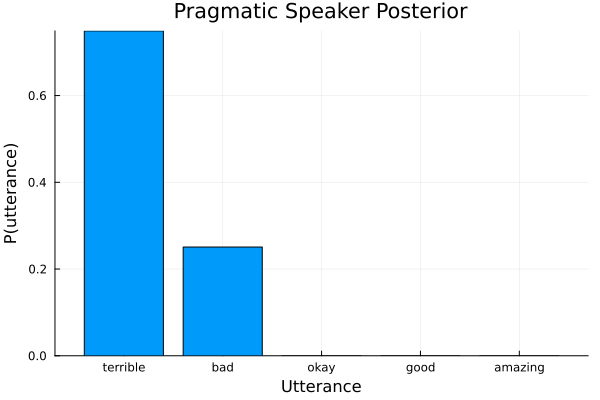

In [12]:
bar(
    utterances, posterior_s1;
    xlabel="Utterance",
    ylabel="P(utterance)",
    title="Pragmatic Speaker Posterior",
    legend=false
)

## L1

In [13]:
phiVals = collect(0.05:0.05:0.95)
phiProbs = uniformProbs(phiVals)
utterances = ["terrible", "bad", "okay", "good", "amazing"]

# A Gen model whose only latent choices are :state, :phi, and :utter
@gen function pragmaticListener()
  # 1) draw state and phi from their priors
  s  = @trace(uniformDraw(states, stateProbs), :state)
  φ  = @trace(uniformDraw(phiVals,  phiProbs),   :phi)

  dict_u = utterProbsDict(s, φ)[2]    #  the S1’s distribution over utterances
  p_u = [ dict_u[u] for u in utterances ]

  utt = @trace(uniformDraw(utterances, p_u), :utter)
  return (state=s, phi=φ)
end

joint_grid = choice_vol_grid(
  (:state, states),
  (:phi,   phiVals)
)

# enumerative inference, conditioning on the observed utterance
observed = "good"
(tr_pl, logw_pl, lml_pl) = enumerative_inference(
  pragmaticListener,
  (),
  choicemap(:utter => observed),
  joint_grid
)

# normalized weights
weights = exp.(logw_pl)

5×19 Matrix{Float64}:
 0.000582388  0.000613738  0.000646763  …  9.27401e-17  2.44014e-18
 0.000917585  0.00151962   0.0025053       3.42948e-13  1.44804e-14
 0.00297721   0.0144249    0.0473355       0.000513019  0.000251844
 0.00070318   0.000894358  0.00113689      0.0296115    0.0345084
 0.000576263  0.000600901  0.000626585     0.00117194   0.00122172

In [14]:
state_post = Dict(
  s => sum(weights[i] for (i,(cm,_)) in enumerate(joint_grid) if cm[:state] == s)
  for s in states
)
phi_post = Dict(
  φ => sum(weights[i] for (i,(cm,_)) in enumerate(joint_grid) if cm[:phi]   == φ)
  for φ in phiVals
)

Dict{Float64, Float64} with 19 entries:
  0.95 => 0.0359819
  0.3  => 0.105522
  0.45 => 0.082515
  0.25 => 0.100999
  0.35 => 0.104699
  0.7  => 0.0232985
  0.85 => 0.0272012
  0.15 => 0.052251
  0.2  => 0.0872069
  0.9  => 0.0312964
  0.65 => 0.0277824
  0.8  => 0.0240759
  0.05 => 0.00575662
  0.5  => 0.0671566
  0.55 => 0.0510122
  0.1  => 0.0180536
  0.4  => 0.0956186
  0.75 => 0.02248
  0.6  => 0.0370927

In [15]:
println("Log-marginal likelihood (pragmaticListener): ", round(lml_pl, digits=3))

println("\nPosterior P(state | utterance=\"$observed\"):")
for s in states
    @printf("  state=%d → %.3f\n", s, state_post[s])
end

println("\nPosterior P(phi   | utterance=\"$observed\"):")
for φ in phiVals
    @printf("  φ=%.2f → %.3f\n", φ, phi_post[φ])
end

Log-marginal likelihood (pragmaticListener): -2.209

Posterior P(state | utterance="good"):
  state=1 → 0.007
  state=2 → 0.046
  state=3 → 0.736
  state=4 → 0.195
  state=5 → 0.016

Posterior P(phi   | utterance="good"):
  φ=0.05 → 0.006
  φ=0.10 → 0.018
  φ=0.15 → 0.052
  φ=0.20 → 0.087
  φ=0.25 → 0.101
  φ=0.30 → 0.106
  φ=0.35 → 0.105
  φ=0.40 → 0.096
  φ=0.45 → 0.083
  φ=0.50 → 0.067
  φ=0.55 → 0.051
  φ=0.60 → 0.037
  φ=0.65 → 0.028
  φ=0.70 → 0.023
  φ=0.75 → 0.022
  φ=0.80 → 0.024
  φ=0.85 → 0.027
  φ=0.90 → 0.031
  φ=0.95 → 0.036


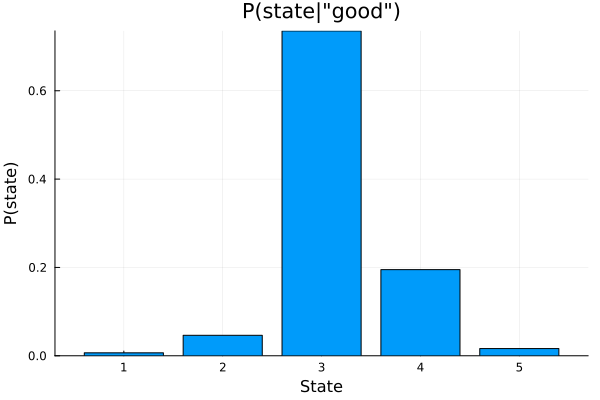

In [16]:
bar(states, [state_post[s] for s in states];
    xlabel="State", ylabel="P(state)",
    title="P(state|\"$observed\")", legend=false)

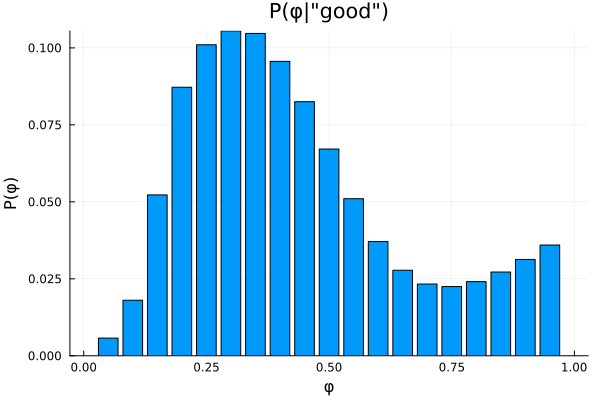

In [17]:
bar(phiVals, [phi_post[φ] for φ in phiVals];
    xlabel="φ", ylabel="P(φ)",
    title="P(φ|\"$observed\")", legend=false)